In [86]:
import pandas as pd
import numpy as np
import seaborn as sns

In [87]:
data = pd.read_csv('../bitcoin_data/raw/btc_binance_daily.csv')
data.head()

,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.93351
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.10277
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.43256
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.52187
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.21867


In [88]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1000 non-null   str    
 1   open    1000 non-null   float64
 2   high    1000 non-null   float64
 3   low     1000 non-null   float64
 4   close   1000 non-null   float64
 5   volume  1000 non-null   float64
dtypes: float64(5), str(1)
memory usage: 47.0 KB


In [89]:
df = data.copy()

### Feature Engineering

* Log Return

In [90]:
periods = [1, 2, 5, 10]

for p in periods:
    col_name = "log_return" if p == 1 else f"log_return_{p}d"
    df[col_name] = np.log(df["close"] / df["close"].shift(p))

In [91]:
df[["log_return", "log_return_2d", "log_return_5d", "log_return_10d"]].isna().sum()

log_return         1
log_return_2d      2
log_return_5d      5
log_return_10d    10
dtype: int64

* Price Ratios

In [92]:
# Price ratios
df["high_low_ratio"] = df["high"] / df["low"]
df["close_open_ratio"] = df["close"] / df["open"]
df["high_close_ratio"] = df["high"] / df["close"]
df["low_close_ratio"] = df["low"] / df["close"]

# Daily range relative to close
df["range_ratio"] = (df["high"] - df["low"]) / df["close"]

# Candle body size relative to close
df["body_ratio"] = abs(df["close"] - df["open"]) / df["close"]

# Upper and lower shadow ratios
df["upper_shadow_ratio"] = (
    df["high"] - df[["open", "close"]].max(axis=1)
) / df["close"]

df["lower_shadow_ratio"] = (
    df[["open", "close"]].min(axis=1) - df["low"]
) / df["close"]

* Rolling Windows

In [93]:
# Rolling stats on log-return
return_windows = [7, 14, 30]

for w in return_windows:
    rolling_return = df["log_return"].rolling(window=w)

    df[f"return_mean_{w}d"] = rolling_return.mean()
    df[f"return_std_{w}d"] = rolling_return.std()
    df[f"return_skew_{w}d"] = rolling_return.skew()
    df[f"return_kurt_{w}d"] = rolling_return.kurt()

# Price distance from rolling highs / lows
price_windows = [7, 30, 90]

for w in price_windows:
    rolling_high = df["high"].rolling(window=w).max()
    rolling_low = df["low"].rolling(window=w).min()

    df[f"dist_from_high_{w}d"] = (df["close"] - rolling_high) / df["close"]
    df[f"dist_from_low_{w}d"] = (df["close"] - rolling_low) / df["close"]

In [94]:
from ta import momentum, trend


def add_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    RSI, MACD, Stochastic, ROC, Williams %R, CCI.
    Source: Jung et al. (2023) — Computer Systems Science & Engineering.
    """


    # RSI — multiple windows
    for w in [9, 14, 21]:
        df[f"rsi_{w}"] = momentum.RSIIndicator(
            close=df["close"],
            window=w
        ).rsi()

    # MACD
    macd_obj = trend.MACD(
        close=df["close"],
        window_slow=26,
        window_fast=12,
        window_sign=9
    )

    df["macd"] = macd_obj.macd()
    df["macd_signal"] = macd_obj.macd_signal()
    df["macd_hist"] = macd_obj.macd_diff()

    # Stochastic Oscillator
    for w in [9, 14, 21]:
        stoch_obj = momentum.StochasticOscillator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            smooth_window=3
        )

        df[f"stoch_k_{w}"] = stoch_obj.stoch()
        df[f"stoch_d_{w}"] = stoch_obj.stoch_signal()

    # Rate of Change — ROC
    for w in [9, 14, 21]:
        df[f"roc_{w}"] = momentum.ROCIndicator(
            close=df["close"],
            window=w
        ).roc()

    # Williams %R
    for w in [9, 14, 21]:
        df[f"williams_r_{w}"] = momentum.WilliamsRIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            lbp=w
        ).williams_r()

    # Commodity Channel Index — CCI
    for w in [14, 20, 30]:
        df[f"cci_{w}"] = trend.CCIIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            constant=0.015
        ).cci()

    return df

In [95]:
from ta import trend


def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    SMA, EMA, TEMA, ADX, PSAR, Ichimoku.
    """


    # Simple Moving Averages
    for w in [7, 21, 50, 200]:
        df[f"sma_{w}"] = trend.SMAIndicator(
            close=df["close"],
            window=w
        ).sma_indicator()

        df[f"price_vs_sma_{w}"] = (
            df["close"] - df[f"sma_{w}"]
        ) / df[f"sma_{w}"]

    # Exponential Moving Averages
    for w in [9, 12, 26]:
        df[f"ema_{w}"] = trend.EMAIndicator(
            close=df["close"],
            window=w
        ).ema_indicator()

    # TEMA: Triple Exponential Moving Average
    for w in [9, 12, 26]:
        ema1 = df["close"].ewm(span=w, adjust=False).mean()
        ema2 = ema1.ewm(span=w, adjust=False).mean()
        ema3 = ema2.ewm(span=w, adjust=False).mean()

        df[f"tema_{w}"] = 3 * ema1 - 3 * ema2 + ema3

    # EMA / SMA crossover features
    df["ema_9_26_cross"] = df["ema_9"] - df["ema_26"]
    df["sma_50_200_cross"] = df["sma_50"] - df["sma_200"]

    # ADX: trend strength
    adx_obj = trend.ADXIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=14
    )

    df["adx"] = adx_obj.adx()
    df["adx_pos"] = adx_obj.adx_pos()
    df["adx_neg"] = adx_obj.adx_neg()

    # Parabolic SAR
    psar = trend.PSARIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"]
    )

    df["psar"] = psar.psar()
    df["psar_up"] = psar.psar_up()
    df["psar_down"] = psar.psar_down()

    # Ichimoku
    ichimoku = trend.IchimokuIndicator(
        high=df["high"],
        low=df["low"],
        window1=9,
        window2=26,
        window3=52
    )

    df["ichimoku_a"] = ichimoku.ichimoku_a()
    df["ichimoku_b"] = ichimoku.ichimoku_b()
    df["ichimoku_base"] = ichimoku.ichimoku_base_line()
    df["ichimoku_conv"] = ichimoku.ichimoku_conversion_line()

    return df

* Volatility Features

In [96]:
from ta import volatility


def add_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bollinger Bands, ATR, Keltner Channel, Donchian Channel.
    """


    # Make sure log_return exists
    if "log_return" not in df.columns:
        df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # Bollinger Bands
    for w in [14, 20]:
        bb = volatility.BollingerBands(
            close=df["close"],
            window=w,
            window_dev=2
        )

        df[f"bb_upper_{w}"] = bb.bollinger_hband()
        df[f"bb_lower_{w}"] = bb.bollinger_lband()
        df[f"bb_width_{w}"] = bb.bollinger_wband()
        df[f"bb_pct_{w}"] = bb.bollinger_pband()

    # Average True Range
    for w in [7, 14]:
        atr = volatility.AverageTrueRange(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w
        )

        df[f"atr_{w}"] = atr.average_true_range()
        df[f"atr_pct_{w}"] = df[f"atr_{w}"] / df["close"]

    # Keltner Channel
    kc = volatility.KeltnerChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["kc_upper"] = kc.keltner_channel_hband()
    df["kc_lower"] = kc.keltner_channel_lband()
    df["kc_width"] = kc.keltner_channel_wband()

    # Donchian Channel
    dc = volatility.DonchianChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["dc_upper"] = dc.donchian_channel_hband()
    df["dc_lower"] = dc.donchian_channel_lband()
    df["dc_width"] = dc.donchian_channel_wband()

    # Historical volatility annualized
    for w in [7, 14, 30]:
        df[f"hist_vol_{w}d"] = (
            df["log_return"].rolling(w).std() * np.sqrt(365)
        )

    return df

In [97]:
df = add_volatility_features(df)
df = add_trend_features(df)
df = add_momentum_features(df)

In [98]:
# 1. Check which columns have missing values
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

psar_down            549
psar_up              453
sma_50_200_cross     199
sma_200              199
price_vs_sma_200     199
                    ... 
dist_from_low_7d       6
dist_from_high_7d      6
log_return_5d          5
log_return_2d          2
log_return             1
Length: 76, dtype: int64


In [99]:
# 3. Fill PSAR direction columns instead of dropping rows
for col in ["psar_up", "psar_down"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [100]:
df.isnull().sum()

date              0
open              0
high              0
low               0
close             0
                 ..
williams_r_14    13
williams_r_21    20
cci_14           13
cci_20           19
cci_30           29
Length: 104, dtype: int64

* Target Feature

In [101]:
df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100

In [102]:
before = len(df)

df_clean = df.dropna().reset_index(drop=True)

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)

Rows before: 1000
Rows after: 800
Rows dropped: 200


In [103]:
df = df.dropna().reset_index()

/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_75585/172591757.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.dropna().reset_index()


### Correlation Metrics

In [104]:
# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with target_pct_change
corr_with_target = numeric_df.corr()["target_pct_change"].sort_values(ascending=False)

print(corr_with_target)

target_pct_change     1.000000
upper_shadow_ratio    0.111274
high_close_ratio      0.081341
volume                0.063900
low_close_ratio       0.051845
                        ...   
ema_26               -0.050568
dc_lower             -0.052146
close                -0.052744
sma_50               -0.052781
bb_lower_20          -0.053249
Name: target_pct_change, Length: 105, dtype: float64


In [105]:
corr_with_target = corr_with_target.drop(
    labels=["target_pct_change"],
    errors="ignore"
)

print(corr_with_target.head(30))
print(corr_with_target.tail(30))

upper_shadow_ratio    0.111274
high_close_ratio      0.081341
volume                0.063900
low_close_ratio       0.051845
return_skew_14d       0.049691
atr_pct_14            0.046433
atr_pct_7             0.044815
return_kurt_14d       0.044205
kc_width              0.043623
return_skew_30d       0.043468
bb_width_20           0.040739
return_skew_7d        0.038251
bb_width_14           0.035032
hist_vol_14d          0.030012
return_std_14d        0.030012
dc_width              0.028915
hist_vol_30d          0.025133
return_std_30d        0.025133
range_ratio           0.020756
dist_from_low_90d     0.020301
cci_14                0.017926
high_low_ratio        0.014943
stoch_d_14            0.014007
stoch_k_14            0.012606
williams_r_14         0.012606
macd_signal           0.012521
adx_pos               0.010773
williams_r_21         0.010322
stoch_k_21            0.010322
cci_20                0.008876
Name: target_pct_change, dtype: float64
sma_200            -0.044371
b

In [106]:
corr_abs = corr_with_target.abs().sort_values(ascending=False)

print(corr_abs.head(30))

upper_shadow_ratio    0.111274
high_close_ratio      0.081341
volume                0.063900
bb_lower_20           0.053249
sma_50                0.052781
close                 0.052744
dc_lower              0.052146
low_close_ratio       0.051845
ema_26                0.050568
kc_lower              0.050395
dc_upper              0.050271
tema_9                0.049955
sma_21                0.049852
return_skew_14d       0.049691
ichimoku_base         0.049685
bb_lower_14           0.049620
kc_upper              0.049225
ema_12                0.048829
high                  0.048761
ema_9                 0.048651
open                  0.048642
tema_12               0.048623
log_return            0.048567
ichimoku_a            0.048399
price_vs_sma_7        0.048321
ichimoku_b            0.048069
low                   0.047939
close_open_ratio      0.047892
index                 0.047212
sma_7                 0.047038
Name: target_pct_change, dtype: float64


In [107]:
df.isnull().sum()

index                0
date                 0
open                 0
high                 0
low                  0
                    ..
williams_r_21        0
cci_14               0
cci_20               0
cci_30               0
target_pct_change    0
Length: 106, dtype: int64

### Split the data

In [108]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

In [109]:
train_df = df.loc[: "2024-12-31"]
test_df = df.loc["2025-01-01" :]

In [110]:
print("Train period:", train_df.index.min(), "to", train_df.index.max())
print("Test period:", test_df.index.min(), "to", test_df.index.max())

Train period: 2024-04-02 00:00:00 to 2024-12-31 00:00:00
Test period: 2025-01-01 00:00:00 to 2026-06-10 00:00:00


In [111]:
drop_cols = ["target_pct_change"]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["target_pct_change"]
y_test = test_df["target_pct_change"]

### LSTM Model

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

* Create LSTM Sequence

In [113]:
def create_sequences(X_data, y_data, lookback=30):
    X_seq = []
    y_seq = []

    for i in range(lookback, len(X_data)):
        X_seq.append(X_data[i-lookback:i])
        y_seq.append(y_data.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [114]:
lookback = 30

X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    lookback=lookback
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    lookback=lookback
)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (244, 30, 104)
y_train_seq: (244,)
X_test_seq: (496, 30, 104)
y_test_seq: (496,)


* Build LSTM model

In [115]:
n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/Users/rajibul/Downloads/Data-Science-Projects/Financial_Market_Crypto/crypto/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,225 (219.63 KB)

 Trainable params: 56,225 (219.63 KB)

 Non-trainable params: 0 (0.00 B)

* Traiin Model

In [116]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.2437 - mae: 1.8995 - val_loss: 5.4503 - val_mae: 1.8060
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.0916 - mae: 1.8894 - val_loss: 5.3987 - val_mae: 1.7993
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.1167 - mae: 1.9211 - val_loss: 5.4208 - val_mae: 1.8081
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1257 - mae: 1.9300 - val_loss: 5.4407 - val_mae: 1.8151
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.1229 - mae: 1.9431 - val_loss: 5.4778 - val_mae: 1.8224
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.2700 - mae: 1.9673 - val_loss: 5.5297 - val_mae: 1.8326
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1935 - mae: 1.9622 - val_loss: 5.5401 - val_mae: 1.8343
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.0905 - mae: 1.9625 - val_loss: 5.5769 - val_mae: 1.8416
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2617 - mae: 

* Predict and Evaluate

In [119]:
y_pred_lstm = model.predict(X_test_seq).flatten()

mae = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2 = r2_score(y_test_seq, y_pred_lstm)

print("LSTM Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
LSTM Regression Results
MAE: 1.6525443955463819
RMSE: 2.35225146769933
R2: -0.011404952100544596


* Compare Actual vs predicted

In [120]:
comparison_lstm = pd.DataFrame({
    "actual": y_test_seq,
    "predicted": y_pred_lstm
}, index=y_test.index[lookback:])

comparison_lstm["error"] = comparison_lstm["actual"] - comparison_lstm["predicted"]
comparison_lstm["abs_error"] = comparison_lstm["error"].abs()

print(comparison_lstm.head(20))

              actual  predicted     error  abs_error
date                                                
2025-01-31 -1.751360   0.214873 -1.966232   1.966232
2025-02-01 -2.916521   0.210348 -3.126869   3.126869
2025-02-02  3.713314   0.207793  3.505521   3.505521
2025-02-03 -3.518644   0.206383 -3.725027   3.725027
2025-02-04 -1.177029   0.224899 -1.401927   1.401927
2025-02-05 -0.060116   0.264573 -0.324689   0.324689
2025-02-06 -0.049247   0.276164 -0.325410   0.325410
2025-02-07 -0.064306   0.281561 -0.345868   0.345868
2025-02-08  0.018674   0.283474 -0.264800   0.264800
2025-02-09  1.003569   0.256681  0.746887   0.746887
2025-02-10 -1.696198   0.263103 -1.959301   1.959301
2025-02-11  2.183994   0.275326  1.908667   1.908667
2025-02-12 -1.289312   0.277200 -1.566512   1.566512
2025-02-13  0.923670   0.277176  0.646493   0.646493
2025-02-14  0.070953   0.276286 -0.205332   0.205332
2025-02-15 -1.487696   0.262902 -1.750598   1.750598
2025-02-16 -0.351776   0.248669 -0.600444   0.

* Plot actual vs Predicted

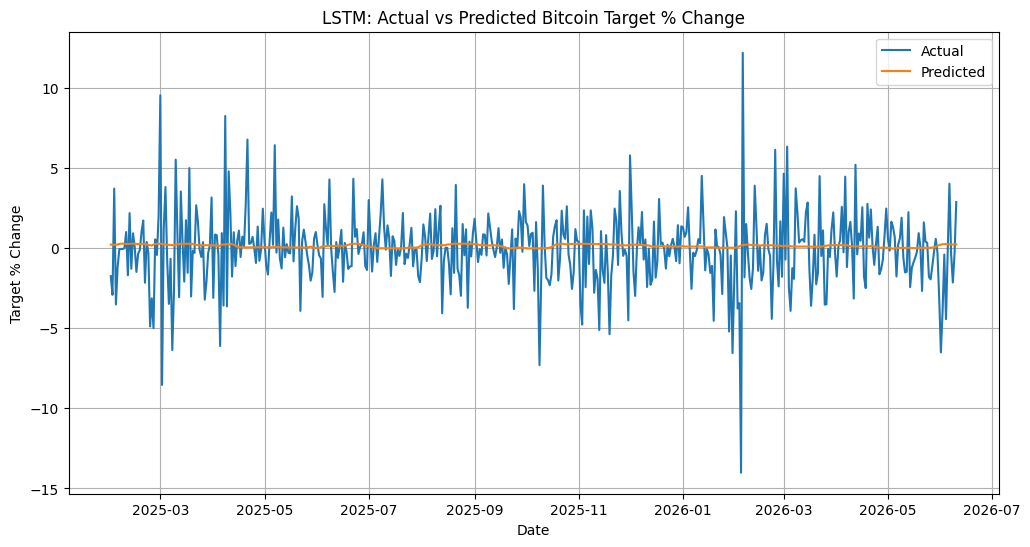

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(comparison_lstm.index, comparison_lstm["actual"], label="Actual")
plt.plot(comparison_lstm.index, comparison_lstm["predicted"], label="Predicted")

plt.title("LSTM: Actual vs Predicted Bitcoin Target % Change")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

* Plot Training History

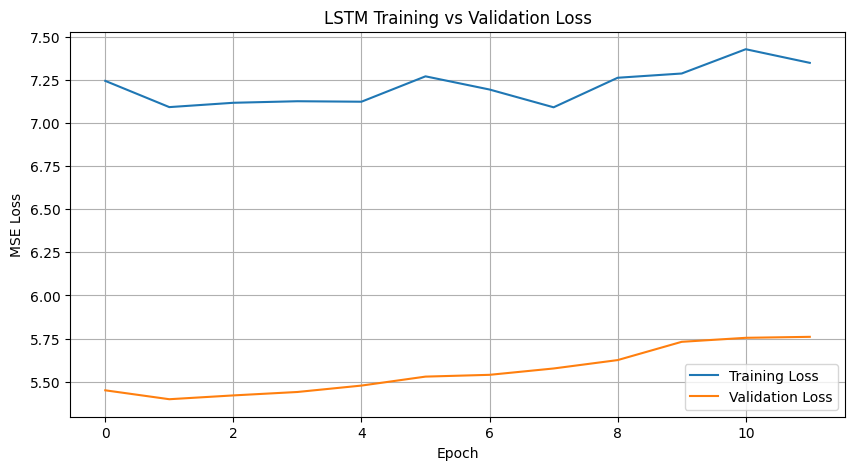

In [122]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()